In [4]:
import os
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from newutils.math import compute_corr_matrix
from oldutils.datasets import ROOT_FOLDER, HydroStaticFeaturesFiles
from config.Constants import ARTIFACTS

os.chdir(ROOT_FOLDER)

In [2]:
OUTDIR = ARTIFACTS / "Fast and Small"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Explore the rivers

In [3]:
import contextily as ctx
print(list(ctx.providers))


['OpenStreetMap', 'MapTilesAPI', 'OpenSeaMap', 'OPNVKarte', 'OpenTopoMap', 'OpenRailwayMap', 'OpenFireMap', 'SafeCast', 'Stadia', 'Thunderforest', 'BaseMapDE', 'CyclOSM', 'Jawg', 'MapBox', 'MapTiler', 'TomTom', 'Esri', 'OpenWeatherMap', 'HERE', 'HEREv3', 'FreeMapSK', 'MtbMap', 'CartoDB', 'HikeBike', 'BasemapAT', 'nlmaps', 'NASAGIBS', 'NLS', 'JusticeMap', 'GeoportailFrance', 'OneMapSG', 'USGS', 'WaymarkedTrails', 'OpenAIP', 'OpenSnowMap', 'AzureMaps', 'SwissFederalGeoportal', 'TopPlusOpen', 'Gaode', 'Strava', 'OrdnanceSurvey', 'UN']


In [4]:
import geopandas as gpd
import polars as pl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load & filter
gdf = gpd.read_file("data/GTS_river_gauges.gpkg")
gdf["gauge_id"] = gdf["gauge_id"].astype(int)
ids = pl.read_csv("data/artifacts/merged_datasets/train_file_ids.csv")["file_id"].to_list()
gdf["lat"], gdf["lon"] = gdf.geometry.y, gdf.geometry.x
train = gdf[gdf["gauge_id"].isin(ids)]

# 2. Compute bounds
min_lon, min_lat, max_lon, max_lat = train.total_bounds
buffer = 0.1

# 3. Create large figure (dimensions in inches)
fig = plt.figure(figsize=(20, 12))
ax  = plt.axes(projection=ccrs.PlateCarree())

# 4. Add high-res Natural Earth 10m features
ax.add_feature(cfeature.LAND.with_scale('10m'))
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.set_extent([min_lon-buffer, max_lon+buffer, min_lat-buffer, max_lat+buffer])

# 5. Plot gauge points (scaled for larger figure)
ax.scatter(
    train["lon"], train["lat"],
    s=100, c="red",
    edgecolor="black", linewidth=0.5,
    alpha=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5,
    label="Gauges"
)

ax.legend(loc="upper right")
ax.set_title("Training River Gauge Locations", pad=12)

# 6. **Save as PDF** (vector format)
plt.savefig(
    "train_gauges_cartopy_10m_large.pdf",  # output filename ends in .pdf
    format="pdf",                          # explicitly PDF
    bbox_inches="tight"
)
plt.close()

In [5]:
import geopandas

gdf = geopandas.read_file("data/GTS_river_gauges.gpkg")
gdf["gauge_id"] = gdf["gauge_id"].astype(int)
gdf

,gauge_id,name_ru,name_en,geometry
0,1500048,ВДХР ИВАНЬКОВСКОЕ - ОГП ДУБНА,VDHR IVAN'KOVSKOE - OGP DUBNA,POINT (37.13125 56.71625)
1,1500056,ВДХР УГЛИЧСКОЕ - Г. КИМРЫ,VDHR UGLIChSKOE - G. KIMRY,POINT (37.36458 56.87375)
2,1500072,ВДХР УГЛИЧСКОЕ - Г. УГЛИЧ,VDHR UGLIChSKOE - G. UGLICh,POINT (38.29958 57.52625)
3,1500099,ВДХР РЫБИНСКОЕ - ПГТ МЫШКИНО,VDHR RYBINSKOE - PGT MYShKINO,POINT (38.45292 57.77542)
4,1500119,ВДХР РЫБИНСКОЕ - С. БРЕЙТОВО,VDHR RYBINSKOE - S. BREJTOVO,POINT (37.88458 58.31292)
...,...,...,...,...
2198,4240,р.Бирюкан - пос.Восточный,r.Birjukan - pos.Vostochnyj,POINT (143.03127 53.49538)
2199,1105,руч.Встреча - выше устья руч.Угроза,ruch.Vstrecha - vyshe ust'ja ruch.Ugroza,POINT (147.66247 61.85056)
2200,4005,р.Охинка - г.Оха,r.Ohinka - g.Oha,POINT (142.93783 53.57969)
2201,76491,р.Чекмагуш - с.Чекмагуш,r.Chekmagush - s.Chekmagush,POINT (54.67846 55.13715)


In [6]:
import polars as pl

polible_ids = pl.read_csv("data/artifacts/merged_datasets/train_file_ids.csv")["file_id"].to_list()

In [7]:
coords = gdf.geometry.apply(lambda p: (p.y, p.x))
gdf["latitude"]  = coords.apply(lambda t: t[0])
gdf["longitude"] = coords.apply(lambda t: t[1])

In [8]:
train_gdf = gdf[gdf["gauge_id"].isin(polible_ids)]

In [9]:
import folium

# 1) Compute center
center_lat = train_gdf["latitude"].mean()
center_lon = train_gdf["longitude"].mean()

# 2) Initialize map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,  # adjust as needed
    tiles="CartoDB positron",
)

# 3) Add each gauge as a marker
for _, row in train_gdf.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,  # marker size in pixels
        color="blue",
        fill=True,
        fill_opacity=0.6,
        popup=row["gauge_id"],  # click to see the English name
    ).add_to(m)

m.save(OUTDIR / "train_river_gauges_map.html")
m

In [10]:
SUBSET_GAUGES = [49095, 70597, 76518, 11379, 74425, 5611, 4005, 1151, 3407, 11571]
SUBSET_GAUGES = [84215, 19170, 5635, 2115, 7015]

In [11]:
import folium

# 1) Compute center
center_lat = train_gdf["latitude"].mean()
center_lon = train_gdf["longitude"].mean()

# 2) Initialize map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,  # adjust as needed
    tiles="CartoDB positron",
)

# 3) Add each gauge as a marker
for _, row in train_gdf.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,  # marker size in pixels
        color="red" if row["gauge_id"] in SUBSET_GAUGES  else "blue",
        fill=True,
        fill_opacity=0.6,
        popup=row["gauge_id"],  # click to see the English name
    ).add_to(m)

m.save(OUTDIR / "train_river_gauges_map.html")
m

# Correlation analysis

In [12]:
SUBSET_GAUGES =  [74425, 4005, 11571, 84215, 2115, 7015]

In [13]:
hsff = HydroStaticFeaturesFiles().dataframe.collect()
hsff.head()

gauge_id,for_pc_sse,crp_pc_sse,inu_pc_ult,ire_pc_sse,lka_pc_use,prm_pc_sse,pst_pc_sse,cly_pc_sav,slt_pc_sav,snd_pc_sav,kar_pc_sse,urb_pc_sse,gwt_cm_sav,lkv_mc_usu,rev_mc_usu,sgr_dk_sav,slp_dg_sav,ws_area,ele_mt_sav,height_bs,lat,lon,dor_pc_pva,clz_cl_smj,cls_cl_smj,tmp_dc_s01,tmp_dc_s02,tmp_dc_s03,tmp_dc_s04,tmp_dc_s05,tmp_dc_s06,tmp_dc_s07,tmp_dc_s08,tmp_dc_s09,tmp_dc_s10,tmp_dc_s11,…,glc_pc_s14,glc_pc_s15,glc_pc_s16,glc_pc_s17,glc_pc_s18,glc_pc_s19,glc_pc_s20,glc_pc_s21,glc_pc_s22,wet_pc_s01,wet_pc_s02,wet_pc_s03,wet_pc_s04,wet_pc_s05,wet_pc_s06,wet_pc_s07,wet_pc_s08,wet_pc_s09,gla_pc_sse,soc_th_sav,swc_pc_syr,swc_pc_s01,swc_pc_s02,swc_pc_s03,swc_pc_s04,swc_pc_s05,swc_pc_s06,swc_pc_s07,swc_pc_s08,swc_pc_s09,swc_pc_s10,swc_pc_s11,swc_pc_s12,ero_kh_sav,hft_ix_s93,hft_ix_s09,acc
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9002,71.405729,1.119471,0.884372,0.0,0.712373,54.037087,1.342302,10.445704,40.55478,49.022949,11.302106,0.038855,290.149989,436.800398,0.0,196.390061,11.175569,115263.989,1532.822907,615.5,51.7262,94.44083,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9022,65.531379,2.092753,0.850662,0.000844,0.521935,48.080969,3.70564,11.533421,41.593354,46.897827,15.741981,0.067115,309.103184,777.139335,93.922382,217.806808,12.00985,184499.118,1472.532227,301.28,53.0149,91.47817,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9053,65.477231,6.702154,0.739894,0.050098,0.479609,35.194722,6.448385,-13.082758,16.096449,18.329181,26.674769,0.182343,281.764329,1863.365536,1081.603192,195.112334,11.133027,302690.417,1191.777106,134.41,55.98,92.8,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9112,86.136616,0.0,0.829694,0.0,1.215289,54.345,0.0,9.48481,39.876825,50.748227,0.0,0.0,234.465511,246.346187,0.0,147.769282,8.59549,15448.834,1461.922957,891.96,52.47762,96.09129,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9115,84.346594,0.0,0.823773,0.0,1.162087,53.083843,0.0,9.552391,39.982812,50.515533,14.287978,0.0,245.966072,488.939411,0.0,163.909537,9.345589,44934.891,1416.189131,789.31,52.48862,94.93266,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [14]:
hsff.drop()

gauge_id,for_pc_sse,crp_pc_sse,inu_pc_ult,ire_pc_sse,lka_pc_use,prm_pc_sse,pst_pc_sse,cly_pc_sav,slt_pc_sav,snd_pc_sav,kar_pc_sse,urb_pc_sse,gwt_cm_sav,lkv_mc_usu,rev_mc_usu,sgr_dk_sav,slp_dg_sav,ws_area,ele_mt_sav,height_bs,lat,lon,dor_pc_pva,clz_cl_smj,cls_cl_smj,tmp_dc_s01,tmp_dc_s02,tmp_dc_s03,tmp_dc_s04,tmp_dc_s05,tmp_dc_s06,tmp_dc_s07,tmp_dc_s08,tmp_dc_s09,tmp_dc_s10,tmp_dc_s11,…,glc_pc_s14,glc_pc_s15,glc_pc_s16,glc_pc_s17,glc_pc_s18,glc_pc_s19,glc_pc_s20,glc_pc_s21,glc_pc_s22,wet_pc_s01,wet_pc_s02,wet_pc_s03,wet_pc_s04,wet_pc_s05,wet_pc_s06,wet_pc_s07,wet_pc_s08,wet_pc_s09,gla_pc_sse,soc_th_sav,swc_pc_syr,swc_pc_s01,swc_pc_s02,swc_pc_s03,swc_pc_s04,swc_pc_s05,swc_pc_s06,swc_pc_s07,swc_pc_s08,swc_pc_s09,swc_pc_s10,swc_pc_s11,swc_pc_s12,ero_kh_sav,hft_ix_s93,hft_ix_s09,acc
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9002,71.405729,1.119471,0.884372,0.0,0.712373,54.037087,1.342302,10.445704,40.55478,49.022949,11.302106,0.038855,290.149989,436.800398,0.0,196.390061,11.175569,115263.989,1532.822907,615.5,51.7262,94.44083,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9022,65.531379,2.092753,0.850662,0.000844,0.521935,48.080969,3.70564,11.533421,41.593354,46.897827,15.741981,0.067115,309.103184,777.139335,93.922382,217.806808,12.00985,184499.118,1472.532227,301.28,53.0149,91.47817,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9053,65.477231,6.702154,0.739894,0.050098,0.479609,35.194722,6.448385,-13.082758,16.096449,18.329181,26.674769,0.182343,281.764329,1863.365536,1081.603192,195.112334,11.133027,302690.417,1191.777106,134.41,55.98,92.8,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9112,86.136616,0.0,0.829694,0.0,1.215289,54.345,0.0,9.48481,39.876825,50.748227,0.0,0.0,234.465511,246.346187,0.0,147.769282,8.59549,15448.834,1461.922957,891.96,52.47762,96.09129,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
9115,84.346594,0.0,0.823773,0.0,1.162087,53.083843,0.0,9.552391,39.982812,50.515533,14.287978,0.0,245.966072,488.939411,0.0,163.909537,9.345589,44934.891,1416.189131,789.31,52.48862,94.93266,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5200058,68.401146,15.103152,0.340974,0.0,0.384527,0.077364,7.312321,17.065903,51.409742,31.616046,66.022923,1.022923,101.226361,138.143266,0.0,51.106017,3.663897,36375.578027,364.787966,137.300003,55.820417,56.912083,0.0,7.074499,41.117479,null,null,null,3.01404,10.615186,15.576218,17.843553,15.062178,9.516619,1.344186,null,…,0.0,0.561605,7.873926,8.280802,5.232092,0.011461,0.369628,0.0,0.022923,0.223496,0.123209,0.0,0.0,0.0,0.0,0.0,0.0,0.002865,0.0,58.097421,80.

In [2]:
import pandas as pd
pd_hsff = pd.read_csv("/home/khuzin/Projects/2025-Project-188/data/river_geo_vector.csv", index_col="gauge_id")
# # pd_hsff[pd_hsff.drop[""] == 0] = pd.NA
# pd_hsff = pd_hsff.dropna(axis=1)
# pd_hsff = pd_hsff.drop(columns=["ws_area"])
# pd_hsff = pd_hsff.drop(
#     columns=(pd_hsff == 0).sum()[((pd_hsff == 0).sum() > 5)].index.to_list()
# )
# pd_hsff

In [6]:
import polars as pl

corr = compute_corr_matrix(pl.from_pandas(pd_hsff).lazy())
corr[corr.isna()] = 1
corr

  0%|          | 0/22 [00:00<?, ?it/s]

,for_pc_sse,crp_pc_sse,inu_pc_ult,ire_pc_sse,lka_pc_use,prm_pc_sse,pst_pc_sse,cly_pc_sav,slt_pc_sav,snd_pc_sav,...,gwt_cm_sav,lkv_mc_usu,rev_mc_usu,sgr_dk_sav,slp_dg_sav,ws_area,ele_mt_sav,height_bs,lat,lon
for_pc_sse,1.000000,-0.742970,0.025068,-0.246708,-0.006993,0.092913,-0.690886,-0.048411,-0.019932,0.154552,...,-0.202283,0.000857,0.016081,-0.036081,0.093604,-0.040769,-0.026452,-0.002255,0.232961,0.218809
crp_pc_sse,-0.742970,1.000000,-0.155035,0.283090,-0.111848,-0.364850,0.605363,0.128906,0.083611,-0.127717,...,-0.029412,-0.033785,-0.010024,-0.259788,-0.378363,-0.027126,-0.272379,-0.202778,-0.269281,-0.411420
inu_pc_ult,0.025068,-0.155035,1.000000,-0.060028,0.390349,-0.086560,-0.100692,-0.041813,-0.072739,0.042650,...,-0.073055,-0.003567,-0.003091,-0.033620,-0.049261,-0.001017,-0.157924,-0.155180,0.109780,-0.048508
ire_pc_sse,-0.246708,0.283090,-0.060028,1.000000,-0.047044,-0.119039,0.230285,0.036723,0.001494,-0.063372,...,0.087687,-0.012237,-0.002060,0.007705,-0.054240,0.084957,-0.015156,-0.089943,-0.207318,-0.145224
lka_pc_use,-0.006993,-0.111848,0.390349,-0.047044,1.000000,-0.077968,-0.098258,-0.147237,-0.171441,-0.008663,...,-0.114016,0.049849,0.018737,-0.087474,-0.117295,0.025167,-0.155902,-0.126171,0.296378,-0.195137
prm_pc_sse,0.092913,-0.364850,-0.086560,-0.119039,-0.077968,1.000000,-0.292497,-0.037798,0.042127,0.047700,...,0.202817,0.035863,-0.009107,0.286204,0.372853,0.088027,0.444039,0.387681,0.237483,0.563134
pst_pc_sse,-0.690886,0.605363,-0.100692,0.230285,-0.098258,-0.292497,1.000000,-0.017466,-0.068843,-0.222313,...,0.229904,0.044073,-0.001744,0.076070,-0.040714,0.095855,0.150422,0.110934,-0.416908,-0.294572
cly_pc_sav,-0.048411,0.128906,-0.041813,0.036723,-0.147237,-0.037798,-0.017466,1.000000,0.984876,0.906611,...,0.074188,-0.435490,-0.038947,0.045902,0.017130,-0.350526,-0.018628,0.035973,-0.151737,-0.020028
slt_pc_sav,-0.019932,0.083611,-0.072739,0.001494,-0.171441,0.042127,-0.068843,0.984876,1.000000,0.894279,...,0.044735,-0.428404,-0.038135,0.044929,0.032091,-0.336790,-0.011312,0.041707,-0.103662,0.079018
snd_pc_sav,0.154552,-0.127717,0.042650,-0.063372,-0.008663,0.047700,-0.222313,0.906611,0.894279,1.000000,...,-0.009767,-0.422981,-0.039137,0.027958,0.023079,-0.349895,-0.030192,0.049308,0.081303,0.014666


In [8]:
clustermap = sns.clustermap(np.abs(corr), cmap="coolwarm", figsize=(10, 10))

clustermap.figure.suptitle("Correlation Heatmap", fontsize=24)

# clustermap.fig.subplots_adjust(top=0.95)
clustermap.figure.tight_layout()
clustermap.figure.savefig(
    "/home/khuzin/Projects/2025-Project-188/artifacts/plots/static_selected_features_heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.close(clustermap.figure)

In [ ]:
clustermap = sns.clustermap(np.abs(corr), cmap="coolwarm", figsize=(10, 10))

clustermap.figure.suptitle("Correlation Heatmap", fontsize=24)

# clustermap.fig.subplots_adjust(top=0.95)
clustermap.figure.tight_layout()
clustermap.figure.savefig(
    OUTDIR / "static_selected_features_heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.close(clustermap.figure)

In [ ]:
SELECTED_STATIC_FEATURES = [
    "ele_mt_sav",
    "gauge_id",
    "lon",
    "for_pc_sse",
    "crp_pc_sse",
    "pst_pc_sse",
    "lat",
    "cly_pc_sav",
    "lka_pc_use",
    "lkv_mc_usu",
    "inu_pc_ult",
    "slt_pc_sav",
    "snd_pc_sav",
]

# Time series overview

In [9]:
from newutils.data import load_train_gauge
from newutils.plots import TSPlotter

In [10]:

class TSPlotStyle:
    def __init__(self, context="paper", style="darkgrid", palette="Set2"):
        self._ctx = sns.plotting_context(context)
        self._sty = sns.axes_style(style)
        self._pal = sns.color_palette(palette)

    def __enter__(self):
        self._ctx.__enter__()
        self._sty.__enter__()
        self._pal.__enter__()
        return None

    def __exit__(self, exc_type, exc_val, exc_tb):
        self._pal.__exit__(exc_type, exc_val, exc_tb)
        self._sty.__exit__(exc_type, exc_val, exc_tb)
        self._ctx.__exit__(exc_type, exc_val, exc_tb)

NameError: name 'm' is not defined

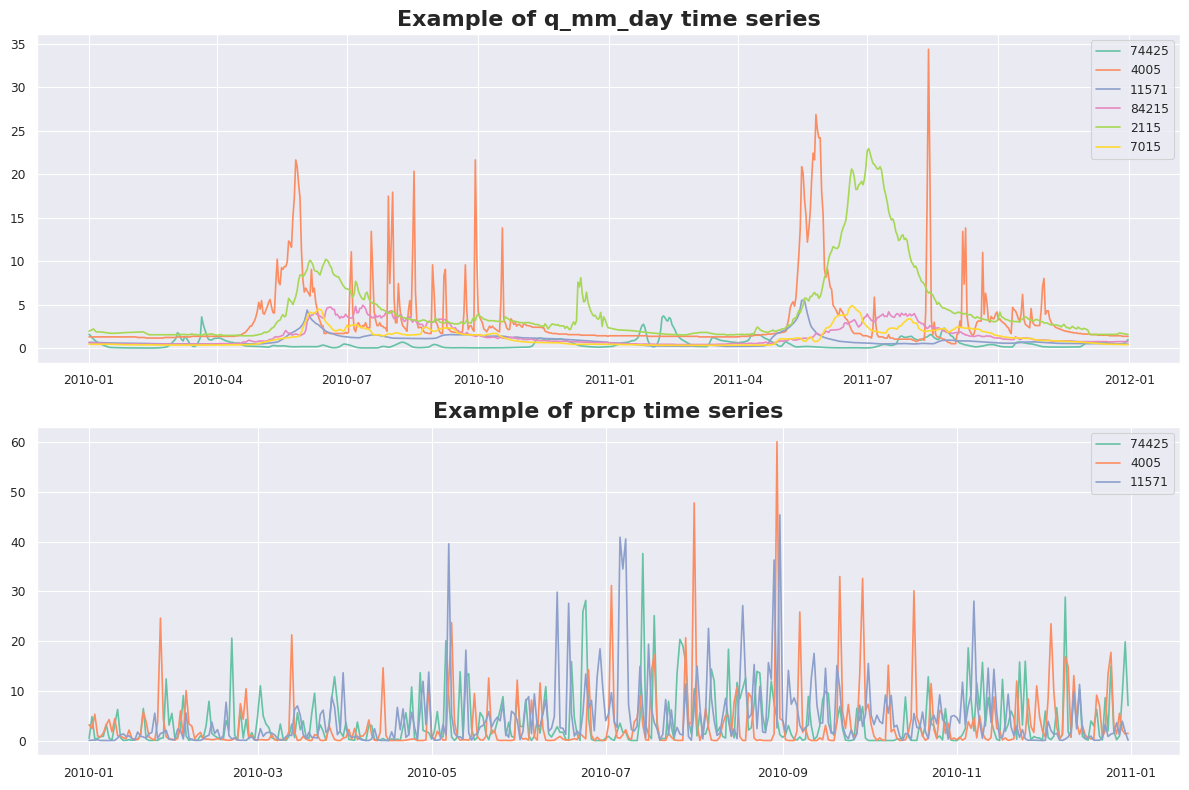

In [11]:
import matplotlib.pyplot as plt

T = [74425, 4005, 11571, 84215, 2115, 7015]

plt.figure(figsize=(12, 8))
for i in T:
    # Load and preprocess
    df = load_train_gauge(i).drop(columns="gauge_id").set_index("date").compute()
    YEARS = [2010, 2011]
    df = df.query("date.dt.year in @YEARS")

    # Plot with your custom style
    with TSPlotStyle():
        plt.subplot(2, 1, 1)
        plt.title("Example of q_mm_day time series", fontdict=TSPlotter.TITLE_FONTDICT)
        plt.plot(df.index, df["q_mm_day"], label=str(i))
        plt.legend()

for i in T[:3]:
    # Load and preprocess
    df = load_train_gauge(i).drop(columns="gauge_id").set_index("date").compute()
    YEARS = [2010]
    df = df.query("date.dt.year in @YEARS")

    # Plot with your custom style
    with TSPlotStyle():
        plt.subplot(2, 1, 2)
        plt.title("Example of prcp time series", fontdict=TSPlotter.TITLE_FONTDICT)
        plt.plot(df.index, df["prcp"], label=str(i))
        plt.legend()

plt.tight_layout()
m
# --- Save as PDF ---
output_path = "target_time_series.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
print(f"Plot saved to {output_path!r}")
# --- End saving ---

plt.show()

/tmp/ipykernel_343338/126791502.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prcp = df["prcp"].resample(PRCP_FREQ).sum()  # monthly totals
/tmp/ipykernel_343338/126791502.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prcp = df["prcp"].resample(PRCP_FREQ).sum()  # monthly totals
/tmp/ipykernel_343338/126791502.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved to 'target_time_series.pdf'


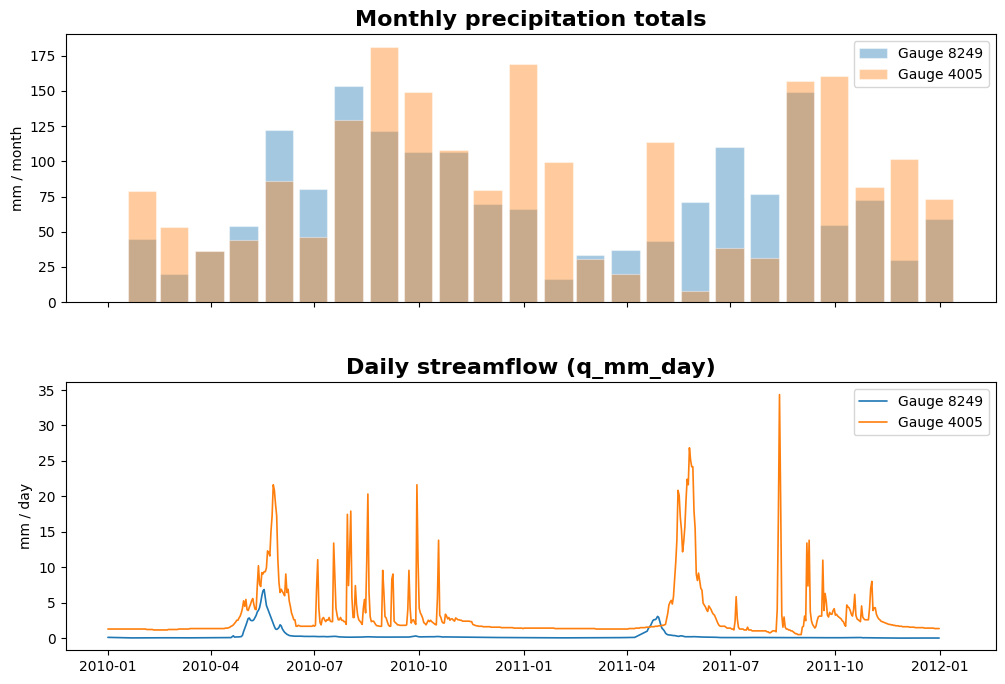

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------
# from your_project.styles import TSPlotStyle, TSPlotter
# from your_project.data   import load_train_gauge
# -------------------------------------------------

GAUGE_IDS = [8249, 4005]  # add more gauges if you like
YEARS = [2010, 2011]  # calendar years to include
PRCP_FREQ = "M"  # **M = monthly bars**   ← changed
FIGSIZE = (12, 8)


def load_and_prepare(gauge_id: int, years):
    """Load one gauge, ensure datetime index, keep only requested years."""
    df = load_train_gauge(gauge_id).drop(columns="gauge_id").compute()  # Dask → Pandas

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.set_index("date")

    return df[df.index.year.isin(years)]


# ── Figure with two aligned axes ─────────────────────────────────────────
fig, (ax_prcp, ax_q) = plt.subplots(
    2, 1, figsize=FIGSIZE, sharex=True, gridspec_kw={"hspace": 0.30}
)

for gid in GAUGE_IDS:
    df = load_and_prepare(gid, YEARS)

    # ── 1. Precipitation bar chart (top) ──
    prcp = df["prcp"].resample(PRCP_FREQ).sum()  # monthly totals
    # Width ~ 25 days so bars almost touch
    width = 25 if PRCP_FREQ == "M" else 0.8

    with TSPlotStyle():
        ax_prcp.bar(
            prcp.index,
            prcp.values,
            width=width,
            align="center",
            label=f"Gauge {gid}",
            alpha=0.4,
        )

    # ── 2. Streamflow line plot (bottom) ──
    with TSPlotStyle():
        ax_q.plot(df.index, df["q_mm_day"], label=f"Gauge {gid}")

# ── Titles, labels, legend ───────────────────────────────────────────────
ax_prcp.set_title("Monthly precipitation totals", fontdict=TSPlotter.TITLE_FONTDICT)
ax_prcp.set_ylabel("mm / month")
ax_prcp.legend()

ax_q.set_title("Daily streamflow (q_mm_day)", fontdict=TSPlotter.TITLE_FONTDICT)
ax_q.set_ylabel("mm / day")
ax_q.legend()

plt.tight_layout()

# ── Save & show ──────────────────────────────────────────────────────────
output_path = "target_time_series.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
print(f"Plot saved to {output_path!r}")

plt.show()